# ループ全体を、一度だけ通す

ベンダーのファイルから意思決定まで、何も飛ばさずに進みます。取り込み、ピン留め、戦略パックからの
戦略づくり、ホールドアウトをショートリストに使うウォークフォワード探索、1つのレポートでの比較、
そして勝者が探索の規模に耐えるかの確認です。取り込みの手順はレシピ 05/06 が詳しく扱うので、ここでは
3行で済ませ、その後に来るものに分量を使います。

個々の手順よりも、順序のほうが重要です。ここで使う h5i-db の機能はどれも、1つの性質を保つために
あります。最後に出てくる数値が、ピン留めされた入力、名前のついた戦略、そして形が記録に残った探索に
帰属できる、という性質です。

## ここで使う用語

| 用語 | 意味 |
| --- | --- |
| 戦略パック | 探索が列挙するパラメータ化された規則の集まり。派生を手書きしなくてよい |
| ウォークフォワード | ある窓で推定し次の窓で検証することを、前へ転がしながら繰り返す |
| ショートリスト | ホールドアウトを使う数少ない候補。ホールドアウトを見ずに選ぶ |
| ホールドアウト | 最後まで手をつけずに取っておくデータ。使えるのは一度きり |
| バスケットレポート | 全実行を横断する1つの比較表。選択を1か所で行うためのもの |
| Brier アドバンテージ | 予測が基準率をどれだけ上回るかを、Brier スコアで表したもの |
| デフレーテッド・シャープ | 試した候補の数だけ下方修正したシャープレシオ |
| ピン留め | 実行の入力を特定のスナップショットに固定すること。最後の数値の帰属先になる |

はじめて見る用語があれば、[GLOSSARY.ja.md](../../GLOSSARY.ja.md) にもう少し詳しい説明があります。ほかのレシピで使う用語もまとめてあります。

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

import cookbook_utils as cu
import h5i_db
from h5i_db import backtest, quant, venues

db = h5i_db.Database(cu.fresh_db("05_end_to_end_workflow"), create=True)
FEE_RATE = 0.07

## 1. 取り込み、そして取り込んだものをピン留めする

ミラーは実物の代わりです。`write_markets` が `instruments` と `resolutions` を書き、
`ingest_archive` が `book_deltas` と `trades` を書きます。以降のすべてを再現可能にするのが
スナップショットの手順です。ここから先、どの読み出しも「そのときテーブルに入っていたもの」ではなく
`mirror-v1` を名指しします。

In [2]:
panel_tables = cu.make_prediction_markets(n_markets=60, steps=32, seed=11)
mirror = Path("data/cache/e2e-mirror")
files = cu.write_polymarket_archive(panel_tables, mirror)
specs = venues.polymarket_markets_from_json(cu.polymarket_market_payloads(panel_tables))

venues.write_markets(db, specs, note="market definitions")
ingest = venues.ingest_archive(
    db, files=files, markets=specs, layout=venues.PMXT_LAYOUT, note="backfill"
)
db.snapshot("mirror-v1", tables=list(venues.CANONICAL_SCHEMAS), note="study input")
print(f"{len(files)} files -> {ingest.rows:,} rows across {len(ingest.tables)} tables")
print(f"gaps: {len(ingest.gaps)}, unrecognised events: {len(ingest.skipped)}")
print({name: write.rows for name, write in sorted(ingest.tables.items())})

10 files -> 10,560 rows across 2 tables
gaps: 0, unrecognised events: 0
{'book_deltas': 8640, 'trades': 1920}


## 2. 気配パネル

1行が1マーケット1瞬間で、パックのどの戦略もこれを使います。`quote_panel` が `expiration_ns` で
止まるのは意図的です。データは決着後も気配を出し続けるので、モメンタムの規則がその 0 や 1 への
跳ねを読むと、実は答えでしかないものをシグナルとして見つけてしまいます。

| 列 | 型 | 意味 |
|---|---|---|
| `ts` | `timestamp[ns]` | 気配の瞬間 |
| `instrument_id` | `string` | マーケット |
| `bid`、`ask` | `float64` | 最良価格。確率として表す |
| `bid_size`、`ask_size` | `float64` | 表示されている板の厚み |

In [3]:
panel = backtest.quote_panel(db, snapshot="mirror-v1")
print(f"{len(panel):,} rows x {len(panel.columns)} columns")
print(f"{panel.instrument_id.nunique()} markets, {panel.ts.nunique()} instants")
expiry = int(db.sql("SELECT max(expiration_ns) AS e FROM instruments").to_pandas()["e"][0])
print(f"panel ends {panel.ts.max()}, expiry {pd.Timestamp(expiry, unit='ns')}")
panel.head()

1,920 rows x 6 columns
60 markets, 32 instants
panel ends 2026-05-01 19:45:00, expiry 2026-05-01 19:45:00


,instrument_id,ts,bid,ask,bid_size,ask_size
0,EVENT-0000,2026-05-01 12:00:00,0.087,0.103,89.826,61.859
1,EVENT-0000,2026-05-01 12:15:00,0.084,0.100,74.195,68.905
2,EVENT-0000,2026-05-01 12:30:00,0.082,0.098,62.506,77.972
3,EVENT-0000,2026-05-01 12:45:00,0.084,0.100,56.045,88.614
4,EVENT-0000,2026-05-01 13:00:00,0.081,0.097,55.524,100.308


## 3. パックから戦略を選ぶ

パックは標準的な規則を、シグナルの「生成器」として提供します。それぞれがテーブルを返し、コール
バックオブジェクトは返しません。だからこそ試行台帳が戦略を内容で識別でき、`verify()` があとから
再現できます。コールバックはより多くをこなせますが、その代わりに内容による同一性を失います。

In [4]:
print("available:", ", ".join(sorted(backtest.STRATEGIES)))
counts = {}
for name, generator in sorted(backtest.STRATEGIES.items()):
    counts[name] = generator(panel).num_signals
print("\nsignals each rule produces on this panel:")
for name, count in sorted(counts.items(), key=lambda item: -item[1]):
    print(f"  {name:24} {count:>5}")

available: breakout, deep_value, ema_crossover, final_period_momentum, late_favorite_hold, mean_reversion, microprice_imbalance, panic_fade, rsi_reversion, threshold_momentum, vwap_reversion



signals each rule produces on this panel:
  rsi_reversion              244
  ema_crossover              172
  microprice_imbalance        81
  threshold_momentum          81
  mean_reversion              48
  breakout                    17
  late_favorite_hold          12
  vwap_reversion              11
  deep_value                   5
  final_period_momentum        1
  panic_fade                   0


ここで `ema_crossover` を選ぶ理由は、規則そのものよりもこのあとの探索にあります。ウォークフォワード
は「時間」で分割するので、どのフォールドの中にも取引が要ります。`late_favorite_hold` のような
決着まで持ち切る規則は1マーケットにつき1回しか取引しないので、ほとんどのフォールドが空になります。
レシピ 05/05 が警告している、中身のない分割そのものです。時間分割で採点できるのは、セッションを
通じて取引する規則のほうです。

プランはパラメータを一緒に持つので、実行のメタデータが、実際にリプレイしたシグナルから離れて
いくことはありません。

In [5]:
plan = backtest.strategies.ema_crossover(
    panel, fast=4, slow=12, quantity=20.0, long_only=True
)
print(f"strategy   {plan.strategy}")
print(f"parameters {plan.parameters}")
print(f"signals    {plan.num_signals}")
db.create_table("signals", plan.signals.schema, time_column="ts")
db.append("signals", plan.signals, note=f"{plan.strategy} {plan.parameters}")
plan.signals.to_pandas().head(3)

strategy   ema_crossover
parameters {'fast': 4, 'slow': 12, 'quantity': 20.0}
signals    271


,ts,instrument_id,outcome,side,quantity,kind,limit_price,time_in_force,tag,reduce_only
0,2026-05-01 12:15:00.000001024,EVENT-0001,0,buy,20.0,market,NaN,NaN,ema_crossover-entry,False
1,2026-05-01 12:15:00.000001024,EVENT-0004,0,buy,20.0,market,NaN,NaN,ema_crossover-entry,False
2,2026-05-01 12:15:00.000001024,EVENT-0005,0,buy,20.0,market,NaN,NaN,ema_crossover-entry,False


## 4. 何かを費やす前にプリフライト

`inspect` は、データが支えられる忠実度を報告し、支えられない主張を拒否します。定期スナップショット
からキューポジションによる約定を求めると、ここでエラーになります。あとになってもっともらしい数値が
出てくることはありません。

In [6]:
def config(
    run_id: str, *, fee_rate_override: float | None = None, **execution
) -> backtest.BacktestConfig:
    return backtest.BacktestConfig(
        run_id=run_id,
        data=backtest.DataConfig(signals="signals", snapshot="mirror-v1"),
        portfolio=backtest.PortfolioConfig(starting_cash=250_000.0),
        execution=backtest.ExecutionConfig(
            fee_kind="kalshi",
            fee_rate=FEE_RATE if fee_rate_override is None else fee_rate_override,
            **execution,
        ),
        output=backtest.OutputConfig(equity_interval_nanos=15 * 60 * 1_000_000_000),
        metadata=plan.to_metadata(),
    )


accepted = backtest.inspect(db, config("preflight"))
print(f"fidelity {accepted.fidelity}, accepted {accepted.ok}")
for issue in accepted.warnings:
    print(f"  warning {issue.code}: {issue.message}")
try:
    backtest.inspect(db, config("queue", queue_position=True)).raise_for_errors()
except ValueError as error:
    print(f"\nqueue claim refused: {str(error).splitlines()[0]}")

fidelity ReplayFidelity.SNAPSHOT_L2, accepted True
  warning snapshot_only: periodic snapshots cannot reconstruct queue transitions between events

queue claim refused: backtest preflight failed: unsupported_queue_claim: queue-position replay is not defensible with snapshot_l2 inputs


## 5. ウォークフォワードで探索し、ホールドアウトはショートリストに使う

学習とホールドアウトを1組だけ作る代わりに、3つのフォールドにします。1つの窓で勝って2つで負ける
候補は、発見とはいえないからです。`TopK` はさらにホールドアウトを第2段階にします。候補は学習側で順位づけ
され、上位の数個だけがアウトオブサンプルで実行され、ほかは一切それに触れません。すべての候補が
触れたホールドアウトは、名前の違う2つめの学習データです。

順位づけの指標は `final_cash` ではなく `realized_pnl` です。フォールドの窓はセッションの途中で
終わるので、境界でポジションを持っている規則は、まだ回収していない現金を使った状態にあります。
`final_cash` では、時間切れの瞬間にたまたまどれだけ資本を出していたかで候補を並べることになります。
窓の端で閉じている指標を選んでください。

In [7]:
stamps = list(
    db.sql("SELECT DISTINCT ts_init FROM book_deltas ORDER BY ts_init").to_pandas().ts_init
)
edges = [0, 8, 12, 16, 20, 24, 28]
walk = backtest.WalkForward.of(
    *[
        backtest.ValidationWindows(
            train=(stamps[edges[index]], stamps[edges[index + 1]]),
            holdout=(stamps[edges[index + 1]], stamps[edges[index + 2]]),
        )
        for index in range(0, len(edges) - 2, 2)
    ]
)
for index, fold in enumerate(walk.folds):
    print(f"fold {index}: train {fold.train[0].time()}-{fold.train[1].time()} "
          f"holdout {fold.holdout[0].time()}-{fold.holdout[1].time()} "
          f"embargo {fold.embargo_ns / 1e9:.0f}s")

fold 0: train 12:00:00-14:00:00 holdout 14:00:00-15:00:00 embargo 0s
fold 1: train 15:00:00-16:00:00 holdout 16:00:00-17:00:00 embargo 0s
fold 2: train 17:00:00-18:00:00 holdout 18:00:00-19:00:00 embargo 0s


In [8]:
study = backtest.study(
    db,
    study_id="e2e-fees",
    base=config("e2e-fees"),
    parameters={"execution.fee_rate": [0.0, 0.02, 0.04, FEE_RATE]},
    validation=walk,
    selection=backtest.TopK(k=2, metric="realized_pnl"),
)
board = pd.DataFrame(study.ranked())
columns = ["trial", "parameters", "train_median_realized_pnl", "holdout_median_realized_pnl"]
print(board[columns].to_string(index=False))
print(f"\ntrials run: {len(study.trials)}, reached the holdout: {len(study.selected)}")
print(f"attention: {study.attention_state}, unseen warnings: {study.warning_badge}")

 trial                   parameters  train_median_realized_pnl  holdout_median_realized_pnl
     0  {"execution.fee_rate": 0.0}                      -0.92                        -0.80
     1 {"execution.fee_rate": 0.02}                      -2.12                        -1.74

trials run: 4, reached the holdout: 2
attention: AttentionState.FAILED_WARNED, unseen warnings: 4


ホールドアウトの列を持つのはショートリストだけです。ご自身の研究でも確認する価値のある性質です。
すべての候補にアウトオブサンプルのスコアが付いているなら、そのアウトオブサンプル集合は
アウトオブサンプルではありません。

In [9]:
for row in sorted(study.trials, key=lambda item: item["trial"]):
    has_holdout = any(key.startswith("fold0_holdout_") for key in row)
    print(f"trial {row['trial']}  selected={row['selected']!s:5} "
          f"holdout_columns={has_holdout}")

trial 0  selected=True  holdout_columns=True
trial 1  selected=True  holdout_columns=True
trial 2  selected=False holdout_columns=False
trial 3  selected=False holdout_columns=False


## 5b. このスイープに何の値打ちがあるのか

手数料のスイープには分かりきった向きがあります。低いほうが常に良いので、順位づけは発見になりません。
役に立つ数値は交差点、つまりこのエッジがエッジでなくなるまでにどれだけの手数料を吸収できるか、です。
すべての候補が学習側のスコアを持つので、ホールドアウトが一度も見なかった試行についても、そのまま
研究結果から読み取れます。

スタディが変えられないものにも注意してください。`data.signals` はデータの同一性に関わるフィールド
なので、「戦略」のパラメータを探索するには、候補ごとに1つの signals テーブルと1回の実行が要ります。
レシピ 05/05 のやり方です。スタディが変えるのは、執行、ポートフォリオ、リスク、出力です。

In [10]:
absorbed = []
for row in sorted(study.trials, key=lambda item: item["trial"]):
    if row["status"] != "ok":
        continue
    rate = json.loads(row["parameters"])["execution.fee_rate"]
    train = row["train_median_realized_pnl"]
    absorbed.append(
        {
            "fee_rate": rate,
            "train_median_realized_pnl": train,
            "profitable": train > 0.0,
            "reached_holdout": row["selected"],
        }
    )
frame = pd.DataFrame(absorbed)
print(frame.to_string(index=False))
survivors = frame[frame.profitable]
if len(survivors) and len(survivors) < len(frame):
    print(f"\nthe edge survives up to a {survivors.fee_rate.max():.2%} fee and "
          f"not at {frame[~frame.profitable].fee_rate.min():.2%}")
else:
    print("\nno crossover inside the swept range: widen it before concluding")

 fee_rate  train_median_realized_pnl  profitable  reached_holdout
     0.00                      -0.92       False             True
     0.02                      -2.12       False             True
     0.04                      -3.24       False            False
     0.07                      -4.92       False            False

no crossover inside the swept range: widen it before concluding


## 6. 勝者を実行し、正しく会計する

`realized_pnl` が対象とするのは決済済みの取引だけです。これらのポジションは決着まで持ち切るので、
結果は `bt_positions.settlement_pnl` に現れます。そして決済が適用されるのは、リプレイが観測可能に
なる瞬間を越えて進んだからです。両方の数値が残るので、持ち切ることに依存する部分を、仮定に頼らず
明示的な数字として示せます。

In [11]:
winner = study.ranked()[0]
best_fee = float(json.loads(winner["parameters"])["execution.fee_rate"])
final = backtest.execute(db, config("e2e-final", fee_rate_override=best_fee))
positions = final.positions.to_pandas()
summary = final.summary()
settled = float(positions.settlement_pnl.fillna(0.0).sum())
marked = float(positions.market_exit_pnl.fillna(0.0).sum())
print(f"winning fee_rate on holdout: {best_fee}")
print(f"fills                 {summary['fills']}")
print(f"realized (round trips){summary['realized_pnl']:>12,.2f}")
print(f"marked to last quote  {marked:>12,.2f}")
print(f"settled at resolution {settled:>12,.2f}")
print(f"settlement adjustment {settled - marked:>+12,.2f}")
print(f"fees                  {summary['commissions']:>12,.2f}")
# realized_pnl is already net of commissions, so the total is realized +
# settlement. Subtracting commissions again double-counts them, and settlement
# alone drops every closed round trip.
print(f"net                   {summary['realized_pnl'] + settled:>12,.2f}")
print(f"settlement applied:   {bool(final.run.to_pandas().settlement_applied.iloc[0])}")

winning fee_rate on holdout: 0.0
fills                 254
realized (round trips)      -44.60
marked to last quote         44.54
settled at resolution        44.98
settlement adjustment        +0.44
fees                          0.00
net                           0.38
settlement applied:   True


どちらかを信じる前に、この2行を合わせて読んでください。`realized_pnl` はこの規則が手仕舞った取引
から得たもので、はっきり負です。クロスオーバーの売買は損をしました。`settlement_pnl` は最後まで
残っていたポジションがどうなったかで、こちらは正ですが、取引の損失を埋めるにはまるで足りません。

合計は2つの和です。この算術をわざわざ書くのは、直感的なもう1つの計算が間違っているからです。
`realized_pnl` にはすでに手数料が入っているので、もう一度引くと二重に数えることになります。そして
決済だけを見ると、規則が建てて閉じたポジションをすべて無視することになり、クロスオーバーの規則では
そのほとんどが該当します。2つの書き方が一致するのは、決着前に何も閉じない場合だけです。そしてまさに
その場合が、この誤りを隠してしまいます。

## 7. その確率は価格より良かったのか

エクイティカーブでは行えない比較です。この戦略が含意する予測は単純です。アスクで買ったので、その
アスクが予測確率です。市場自身の予測はミッドです。`brier_advantage` は実現した結果に対して両方を
採点するので、ポジションの大きさでは水増しできません。

In [12]:
fills = final.fills.to_pandas()
truth = cu.market_truth(panel_tables).to_pandas().set_index("instrument_id")
mids = panel.groupby("instrument_id").apply(
    lambda group: group.sort_values("ts").iloc[len(group) // 2], include_groups=False
)
scored = pd.DataFrame(
    {
        "strategy": fills.groupby("instrument_id").price.mean(),
        "market": ((mids.bid + mids.ask) / 2),
    }
).dropna()
scored["outcome"] = truth.yes_won.astype(float)
scored = scored.dropna()
advantage = quant.brier_advantage(
    scored.strategy.tolist(), scored.market.tolist(), scored.outcome.tolist()
)
print(f"markets scored     {advantage.observations}")
print(f"strategy Brier     {advantage.strategy_brier:.4f}")
print(f"market   Brier     {advantage.market_brier:.4f}")
print(f"advantage          {advantage.advantage:+.4f}")
print(f"skill score        {advantage.skill_score:+.3f}")
print(f"beat the market on {advantage.win_rate:.0%} of markets")

markets scored     60
strategy Brier     0.1682
market   Brier     0.1688
advantage          +0.0006
skill score        +0.003
beat the market on 50% of markets


## 8. すべての実行を1つのレポートに

スイープは試行ごとに1つのフォークを残しますが、1つずつ開いて見るのは比較ではありません。バスケット
レポートは、保存されたテーブルから1つの文書を組み立てます。再シミュレーションはしません。まず
ポートフォリオのパネル、バスケットが読める大きさのうちは実行ごとのパネル、そして約定が実際に
ぶつかった板の上に約定のマーカーを載せます。

In [13]:
runs = {"final": final}
for row in study.selected:
    fork = row.get("fold0_holdout_fork") or row.get("fold0_train_fork")
    if fork:
        runs[f"trial{row['trial']}"] = backtest.open_result(db, fork.removeprefix("bt-"))
report = quant.basket_payload(
    db,
    runs,
    basket_id="late-favorite basket",
    panels=quant.PORTFOLIO_PANELS + ("equity", "price", "allocation"),
    snapshot="mirror-v1",
    brier={
        "final": {
            "strategy": scored.strategy.tolist(),
            "market": scored.market.tolist(),
            "outcome": scored.outcome.tolist(),
        }
    },
)
print(f"runs      {report.totals['runs']}")
print(f"net       {report.totals['net']:,.2f}")
print(f"drawdown  {report.totals.get('max_drawdown', 0):.4f}")
print(f"panels    {', '.join(report.drawn)}")
if report.skipped:
    print(f"not drawn {[item['panel'] for item in report.skipped]}")
path = report.to_html("data/cache/e2e-basket.html")
print(f"\nwrote {len(path):,} bytes of self-contained HTML")

runs      3
net       -2.16
drawdown  -0.0001
panels    total_equity, total_drawdown, total_rolling_sharpe, total_cash_equity, periodic_pnl, leaderboard, equity, price, allocation



wrote 306,313 bytes of self-contained HTML


## 9. 勝者は、それを見つけた探索に耐えるか

4候補は小さな探索ですし、パネルも小さいので、誠実な期待は「まだ判定できない」です。シャープレシオを
挙げるより、あと何観測必要かを挙げるほうが役に立ちます。

In [14]:
equity = final.equity.to_pandas().sort_values("ts")
levels = equity.equity.tolist()
returns = [
    (levels[index] - levels[index - 1]) / levels[index - 1]
    for index in range(1, len(levels))
    if levels[index - 1]
]
deflated = quant.deflated_sharpe(returns, trials=len(study.trials))
track = quant.minimum_track_record_length(returns)
print(f"observed Sharpe            {deflated.sharpe:.3f}")
print(f"benchmark after {deflated.trials} trials  {deflated.benchmark:.3f}")
print(f"P(true Sharpe > benchmark) {deflated.probability:.3f}")
if track == float("inf"):
    print("observations needed        no finite length suffices: the observed")
    print("                          Sharpe sits below the deflated benchmark")
else:
    print(f"observations needed        {track:.0f}, available {len(returns)}")
print(f"skew {deflated.skew:+.2f}, excess kurtosis {deflated.kurtosis:.2f}")

observed Sharpe            -0.000
benchmark after 4 trials  0.178
P(true Sharpe > benchmark) 0.150
observations needed        no finite length suffices: the observed
                          Sharpe sits below the deflated benchmark
skew +5.06, excess kurtosis 29.32


必要なトラックレコードが無限になるのは不具合ではありません。観測されたシャープレシオが、4試行に対して
割り引きが設定するベンチマークを下回っているので、どれだけデータを足しても「この」結果が有意になる
ことはない、という意味です。誠実な報告は、探索がエッジを見つけられなかった、というものです。よく
ある結末であり、そう言えることに価値のある結末です。

シャープレシオより先に、歪度と尖度が結論を説明してくれます。決着まで持ち切るブックは、平らなまま
進んで跳ねるので、リターンの分布はノイズに囲まれた1つの外れ値になります。シャープレシオはずっと
正規分布に近いものを前提にしています。このペイオフの形には、レシピ 05/03 の価格帯ごとの持ち切り
リターンのほうが良い推定量です。それでも割り引きを走らせる価値はあります。心地よい数値を報告する
代わりに、そう告げてくれるからです。

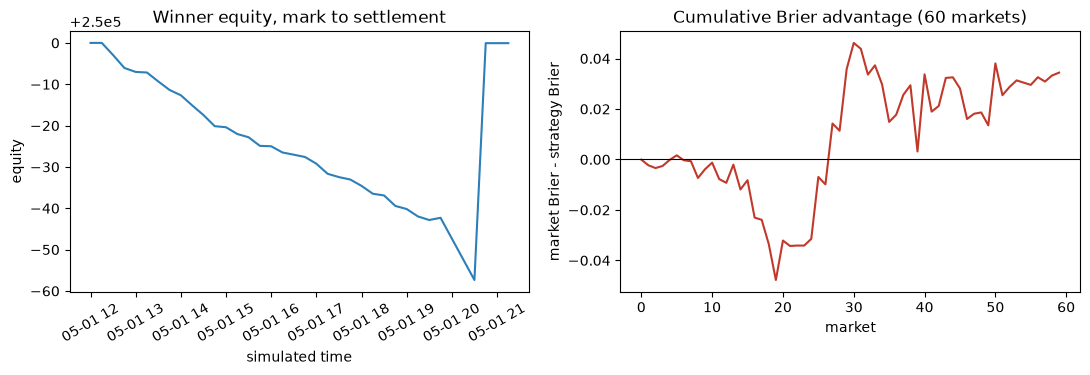

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(equity.ts, equity.equity, color="#2c7fb8")
axes[0].set_title("Winner equity, mark to settlement")
axes[0].set_xlabel("simulated time")
axes[0].set_ylabel("equity")
axes[0].tick_params(axis="x", labelrotation=30)
axes[1].plot(advantage.cumulative, color="#c0392b")
axes[1].axhline(0.0, color="black", lw=0.8)
axes[1].set_title(f"Cumulative Brier advantage ({advantage.observations} markets)")
axes[1].set_xlabel("market")
axes[1].set_ylabel("market Brier - strategy Brier")
fig.tight_layout()

## 10. 記録から再現する

このパイプライン全体が支えようとしている、ただ1つの主張です。`verify()` は保存された設定を作業用
フォークで再実行し、すべての指標と4つの結果テーブルを1行ずつ突き合わせます。変数で持ち回ったものは
何もありません。ピンもシグナルも設定も、すべてデータベースから読み直しています。

In [16]:
verified = final.verify()
print(f"verified: {verified['verified']}")
print(f"tables compared: {list(verified['tables_equal'])}")
print(f"all equal: {all(verified['tables_equal'].values())}")
print(f"\nconfig digest {final.config.digest[:16]}")
print(f"trial digest  {final.config.trial_digest[:16]} (excludes run_id and metadata)")
print(f"data pin      {final.config.data.snapshot}")

verified: True
tables compared: ['bt_orders', 'bt_fills', 'bt_positions', 'bt_equity']
all equal: True

config digest 036d0028c1501535
trial digest  9dd7b71a6de35f6b (excludes run_id and metadata)
data pin      mirror-v1


## まとめ

- ループはこうなる。取り込み、ピン留め、パネル、戦略、プリフライト、探索、会計、レポート、割り引き、
  検証。ピン留めを飛ばすとその後がすべて壊れ、割り引きを飛ばすと最後の数値が見た目より軽くなる。
- `TopK` を使ったウォークフォワードは、ホールドアウトをホールドアウトのまま保つ。アウトオブサンプル
  の列を持つのがショートリストだけかを確認すること。全部が持っているなら、学習データが2つある。
- 合計は `realized_pnl + settlement_pnl` であり、それだけである。前者にはすでに手数料が引かれて
  いるので、もう一度引くと二重計上になる。決済だけを見ると、規則が閉じたポジションをすべて落として
  しまう。ここでは取引の損失が決済の戻りを上回ったので、この実行は損である。決着まで持ち切る規則なら
  2つの書き方が一致し、この区別をまるごと隠してしまう。
- 並べて置いた `market_exit_pnl` が、結果のうちどれだけが持ち切ることに依存しているかを教える。
  そして決済が適用されたのは、リプレイが観測可能になる瞬間を越えて進んだからである。
- 順位づけの指標は、窓の端で閉じているものを選ぶ。フォールド内の `final_cash` は、成績よりも
  投入した資本で候補を並べてしまう。
- `brier_advantage` は、予測が価格を上回ったかを問う。エクイティカーブには答えられず、ポジションの
  大きさでも水増しできない問いである。
- ここで働いた h5i-db の機能。コンテンツアドレス方式の取り込み、すべての読み出しの背後にある名前付き
  スナップショット、フォールドどうしが汚し合わないよう試行ごとに1つ用意したフォーク、実行を1つの
  レポートで比較できるようにする `bt_equity`、そして記録から結果が再現できることを示す `verify()`。
  このセッションには依存しない。

In [17]:
db.close()